In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r'C:\FBS\Data Analysis\classification\Customer_Actions.csv')

In [2]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [4]:
df.drop('User ID',axis=1,inplace=True)

In [5]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [6]:
df_gender=pd.get_dummies(df.Gender,drop_first=True,dtype=int)

In [7]:
df_gender


,Male
0,1
1,1
2,0
3,0
4,1
...,...
345,0
346,1
347,0
348,1


In [8]:
df.drop('Gender',axis=1,inplace=True)
df=pd.concat([df,df_gender],axis=1)
df.head()

,Age,EstimatedSalary,Purchased,Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1


In [9]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
min_max=MinMaxScaler()
df_normalised=min_max.fit_transform(df[['EstimatedSalary']])
df_normalised=pd.DataFrame(df_normalised,columns=['EstimatedSalary'])

In [12]:
df_normalised

,EstimatedSalary
0,0.029630
1,0.037037
2,0.207407
3,0.311111
4,0.451852
...,...
345,0.355556
346,0.422222
347,0.688889
348,0.459259


In [13]:
df.drop('EstimatedSalary',axis=1,inplace=True)
df=pd.concat([df,df_normalised],axis=1)
df.head()

,Age,Purchased,Male,EstimatedSalary
0,19,0,1,0.029630
1,35,0,1,0.037037
2,26,0,0,0.207407
3,27,0,0,0.311111
4,19,0,1,0.451852


<Axes: xlabel='Age', ylabel='Male'>

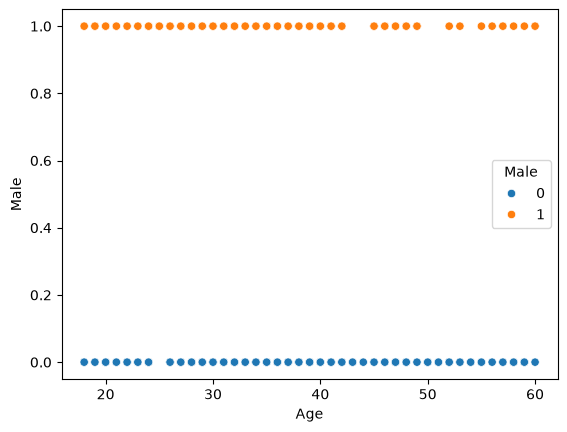

In [18]:
import seaborn as sns
sns.scatterplot(x='Age',y='Male',data=df,hue='Male')

In [20]:
x=df.drop('Purchased',axis=1)
y=df.Purchased

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)

0.8285714285714286